Gradient Descent is an optimization algorithm used to minimize a function (often a loss function in machine learning). The idea is to adjust parameters step by step in the direction that reduces the error until we (hopefully) reach the minimum.

In [1]:
from sklearn.datasets import make_regression
import numpy as np

In [2]:
X, y = make_regression(n_samples=4, n_features=1,n_informative=1, n_targets=1, noise=10, random_state=13)

In [3]:
X

array([[-0.71239066],
       [ 0.45181234],
       [-0.04450308],
       [ 0.75376638]])

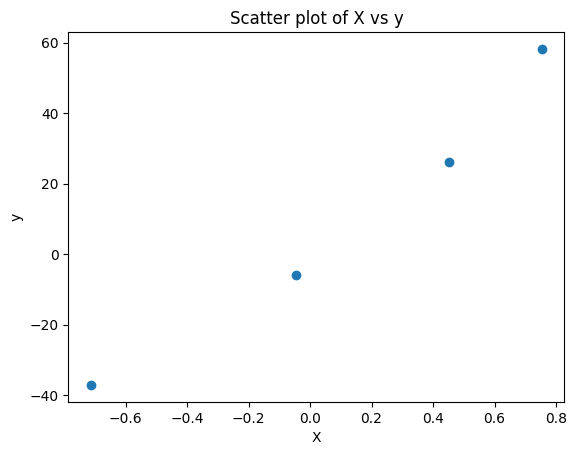

In [16]:
import matplotlib.pyplot as plt
plt.scatter(X, y)
plt.xlabel("X")
plt.ylabel("y")
plt.title("Scatter plot of X vs y")
plt.show()


In [5]:
#apply OLS
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X, y)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [6]:
model.coef_

array([63.08504508])

In [7]:
model.intercept_

3.26995410539158

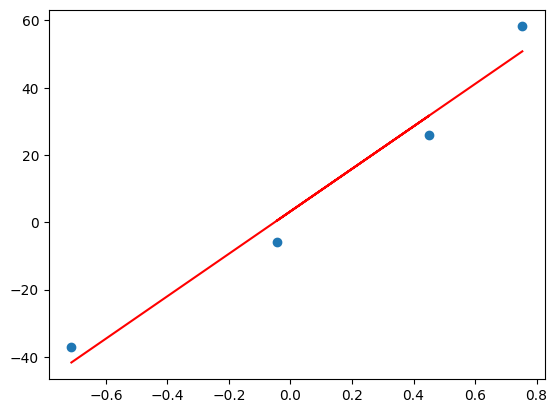

In [8]:
plt.scatter(X, y)
plt.plot(X, model.predict(X), color='red')

In [9]:
# Lets apply gradient desent assuming slope is constant m = 63.08
# and let's assume the intercept is b = 0
y_pred = (63.08 * X + 0).reshape(4)

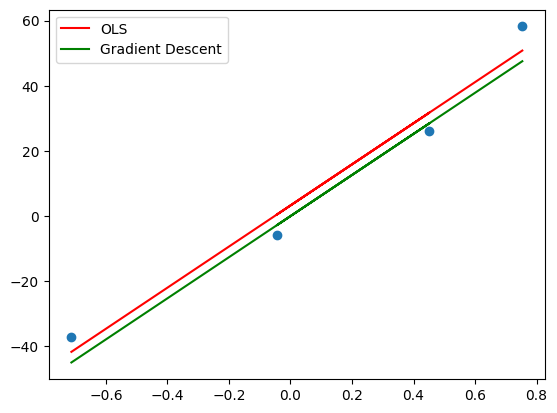

In [10]:
plt.scatter(X, y)
plt.plot(X,model.predict(X), color='red',label='OLS')
plt.plot(X, y_pred, color='green', label='Gradient Descent')
plt.legend()

In [11]:
m = 63.08
b = 0
loss_slope = -2 * np.sum(y - m* X.ravel() - b)
loss_slope

-26.16416014324098

In [12]:
lr = 0.1
step_size = lr * loss_slope
step_size

-2.6164160143240984

In [13]:
b = b - step_size
b

2.6164160143240984

In [14]:
y_pred1 = (m * X + b).reshape(4)


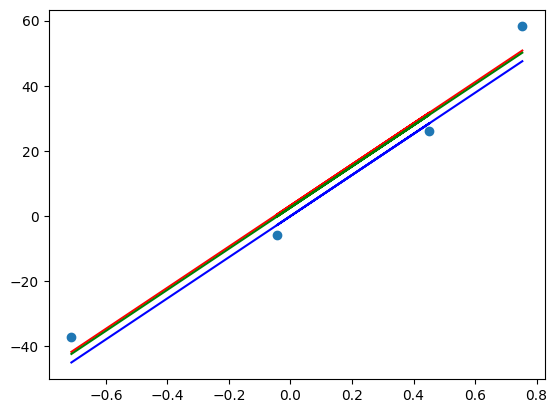

In [15]:
plt.scatter(X, y)
plt.plot(X, model.predict(X), color='red')
plt.plot(X, y_pred1, color='green', label='Gradient Descent')
plt.plot(X, y_pred, color='blue', label='Initial Gradient Descent')